# Bank Customer Segmentation with K-Means Clustering

This notebook groups bank transactions into customer segments using **K-Means clustering**. The resulting cluster labels are exported as a `Target` column, which is later used to train a classification model.

**Workflow**
1. Load and explore the dataset
2. Clean and preprocess the data (missing values, duplicates, irrelevant columns, encoding, outliers, scaling, binning)
3. Choose the number of clusters and train K-Means
4. Evaluate and visualize the clusters (Silhouette Score, PCA)
5. Interpret each cluster in scaled and original units
6. Export the labeled datasets

## 1. Import Libraries
Data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), modeling (`scikit-learn`), cluster-count selection (`yellowbrick`), and model persistence (`joblib`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

## 2. Load the Dataset

The dataset contains bank transaction records: transaction attributes (amount, type, channel, duration), customer demographics (age, occupation), account balance, and login activity. It was provided in the Dicoding *Belajar Machine Learning untuk Pemula* (BMLP) course and is loaded directly from a published Google Sheets CSV.

In [2]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

df.head()


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


The raw data has **2,537 rows and 16 columns**. The non-null counts show that every column has some missing values, which are handled in the cleaning step.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance           2510 non-n

Descriptive statistics for the numeric columns, used to spot value ranges and skew before cleaning.

In [4]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


Store the numeric column names so the same list can be reused for EDA, outlier handling, scaling, and the inverse transform.

In [5]:
numerical_cols = df.select_dtypes(include=['number']).columns

## 3. Exploratory Data Analysis

### Correlation between numeric features
A heatmap of pairwise correlations shows whether any numeric features are strongly related (and therefore redundant).

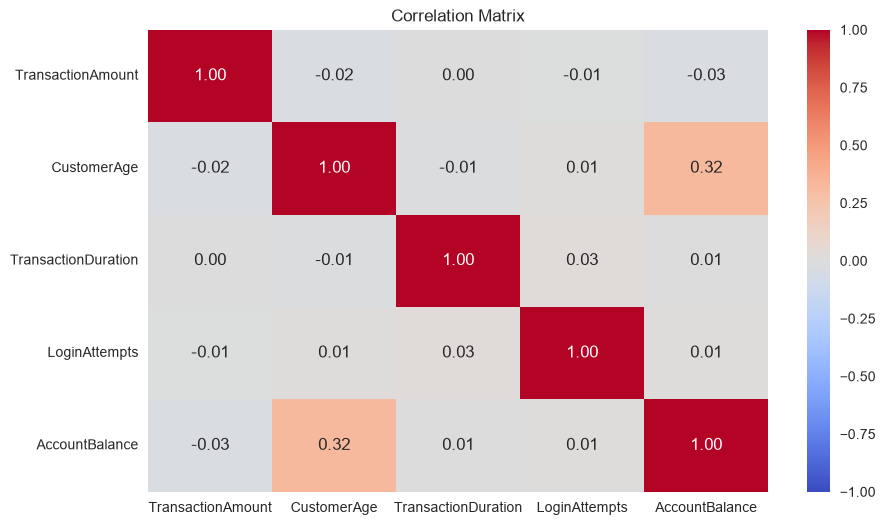

In [6]:
# Count correlation matrix

correlation = df[numerical_cols].corr()

# Create a visualization
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

### Distribution of numeric features
Histograms with a KDE curve show the shape of each numeric feature: skewness, spread, and possible outliers.

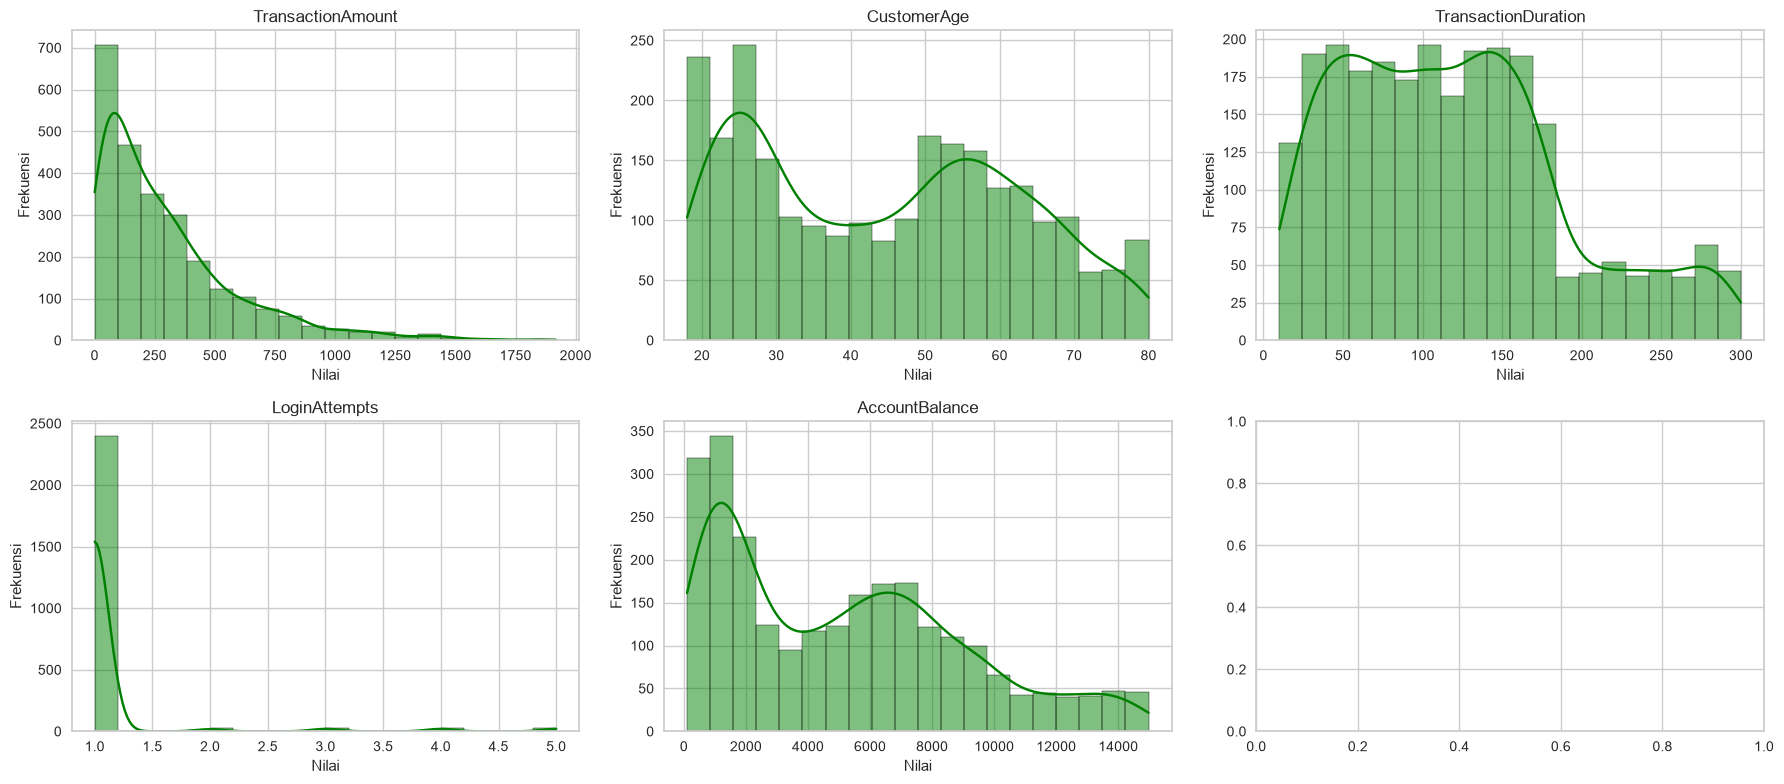

In [7]:
# Showing histogram for numeric columns

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Showing histogram and make sure the plot is placed in the axes (subplot)
    sns.histplot(df[column], bins=20, kde=True, color='green', ax=axes[i])

    # Titles and Labels
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

### Transaction amount by occupation
A boxplot compares the spread of `TransactionAmount` across customer occupations.

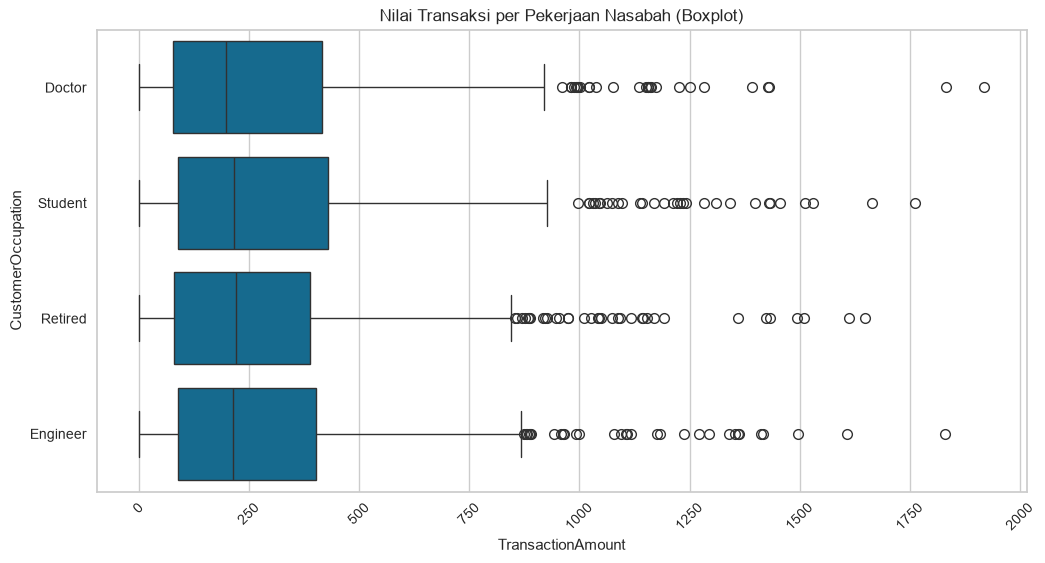

In [8]:
# More informative Visualization

plt.figure(figsize=(12, 6))

# Creating a boxplot visualization to show the 'TransactionAmount'(y) spread by 'CustomerOccupation' (x)

sns.boxplot(x='TransactionAmount', y='CustomerOccupation', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Rotate the x
plt.xticks(rotation=45)
plt.show()

## 4. Data Cleaning and Preprocessing

### Check missing values
Every column has between 18 and 30 missing values.

In [9]:
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
PreviousTransactionDate    28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate            24
dtype: int64

### Check duplicate rows
The dataset contains 21 duplicated rows.

In [10]:
df.duplicated().sum()

np.int64(21)

### Drop missing values
Missing values are scattered across all columns and make up a small share of the data, so rows with any missing value are removed.

In [11]:
# Call a function to delete a row 
df.dropna(inplace=True)

# Re-check dataset using isnull().sum()
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
dtype: int64

### Drop duplicates
Duplicate rows would give some transactions extra weight in the clustering, so they are removed.

In [12]:
# Call the function to delete the duplicate rows
df.drop_duplicates(inplace=True)

# check once again the dataset using duplicated().sum()
df.duplicated().sum()

np.int64(0)

### Drop irrelevant columns
The following columns are removed:
- **ID columns and IP Address**: unique per row, so they carry no information for grouping customers.
- **Date columns**: raw timestamps that are not used as features in this analysis.
- **`Location`**: 43 unique cities. Label encoding would turn them into numbers in alphabetical order, which creates distances between cities that don't mean anything. In an earlier version, this single column dominated K-Means and the clusters simply split the cities into two alphabetical halves.

In [13]:
cols_to_drop = [col for col in df if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower() or
                'location' in col.lower()]

# use .drop() to delete columns in 'cols_to_drop'
df = df.drop(columns=cols_to_drop)

# Showing the first 5 rows
df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,ATM,18.0,Student,172.0,1.0,781.68


### Encode categorical features
Each categorical column (`TransactionType`, `Channel`, `CustomerOccupation`) is converted to integers with `LabelEncoder`. Every fitted encoder is stored in the `encoders` dictionary so the labels can be restored later.

In [14]:
# Select the column that has an type of 'object'
categorial_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop in every categorical columns
for column in categorial_cols:
    # Instantiate LabelEncoder object
    label_encoder = LabelEncoder()

    # Fit the encodet into the data and transform the data
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Show the first 5 to verify the result
df.head()

C:\Users\selyr\AppData\Local\Temp\ipykernel_24240\3081646415.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorial_cols = list(df.select_dtypes(include=['object']).columns)


,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,0,18.0,3,172.0,1.0,781.68


The dataset now contains 8 features.

In [15]:
# Check all the features using columns.tolist()
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

### Handle outliers (IQR method)
For each numeric column, rows outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` are dropped. After this step, **1,945 rows** remain.

In [16]:
# Handling Outlier Data using Drop Method

for col in numerical_cols:
    # count the Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Count the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Set the lower bound and upper bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame - Save where the 'df[col]' value between (inclusive) the lower bound and upper bound
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Show the descriptive statistic after the outliner is cleaned
df.describe() 

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


### Scale numeric features
`StandardScaler` rescales numeric features to mean 0 and standard deviation 1, so features with large ranges (like `AccountBalance`) do not dominate the distance calculation in K-Means.

In [17]:
# Create (instantiate) StandardScaler
scaler = StandardScaler()

# Fit the scaler into the data and transform the data
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Show the first 5 row to verify the result
df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,0,-1.504776,3,0.747704,0.0,-1.105726


### Bin customer age
`CustomerAge` is split into three equal-sized groups (`Low`, `Medium`, `High`) with `pd.qcut`, then label-encoded. The new column `BinnedCustomerAge` is added to the categorical columns so it can also be restored in the inverse step.

In [18]:
# Set the numeric column 
col_to_bin = 'CustomerAge'

# Set the new name for new categorical columns
new_col_name = 'BinnedCustomerAge'

# Set the label into 3 groups
bin_labels = ['Low', 'Medium', 'High']

# Use pd.qcut to divide data into 3 groups
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Do LabelEncoding to this new column to convert it as a numeric
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Save the encoder and add new column to 'categorial_cols'
encoders[new_col_name] = label_encoder
categorial_cols.extend([new_col_name])

# Show the first 5 rows to verify
df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge
0,-1.111922,1,0,1.426636,0,-0.541568,0.0,0.002918,0
1,0.546926,1,0,1.313889,0,0.308502,0.0,2.216531,0
2,-0.597984,1,2,-1.448403,3,-0.895763,0.0,-1.018513,1
3,-0.331350,1,2,-1.053790,3,-1.334965,0.0,0.887895,1
5,-0.754364,1,0,-1.504776,3,0.747704,0.0,-1.105726,1


## 5. Clustering Model

`df_used` is a copy of the fully preprocessed data. It is used for cluster interpretation and export, so the original `df` stays unchanged.

In [19]:
# Create a copy of df into df_used variable
df_used = df.copy()

# Describe the statistic from df_used
df_used.describe()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge
count,1.945000e+03,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,1.001028
std,1.000257e+00,0.419830,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.810171
min,-1.175271e+00,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


### Choose the number of clusters
`KElbowVisualizer` fits K-Means for k = 2–9 and plots the Silhouette Score for each k (higher means better separated clusters).

Note: the visualizer uses a K-Means model without a fixed `random_state`, so individual points on the curve can change between runs (in this run the k = 3 point is unusually low).

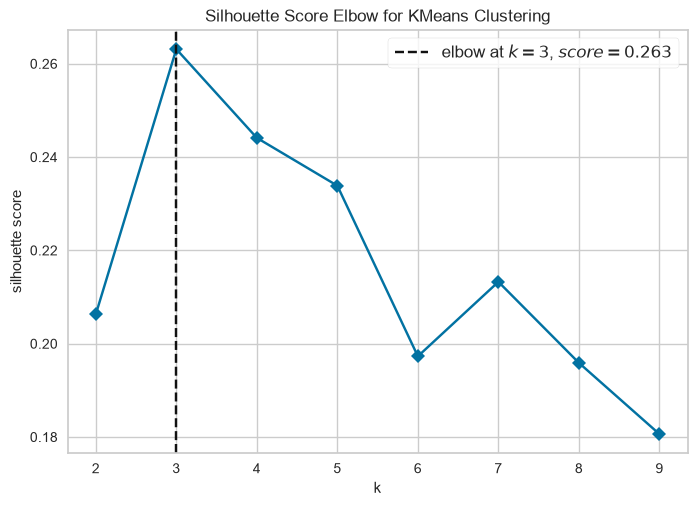

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [20]:
# Instantiate Clustering model
model = KMeans()

visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

# Fit the visualizer into the data
visualizer.fit(df)

# Show the plot
visualizer.show()

### Train K-Means
**k = 3** is used. With a fixed `random_state=42`, k = 3 reaches a Silhouette Score of **0.263**, which is higher than the k = 2 value shown on the curve (0.244). It also produces three clearly different customer groups (see the interpretation below).

In [21]:
# Instantiate the KMeans Object Model, and decide how many clusters you want to use (n_clusters)
model = KMeans(n_clusters=3, random_state=42)

# Fit model with the data
model.fit(df)

KMeans(n_clusters=3, random_state=42)

Save the trained model so it can be reused without retraining.

In [22]:
# Save the clustering model that has been trained with joblib
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']

### Evaluate with Silhouette Score
The score ranges from −1 to 1. A score of **0.263** means the clusters are separated, but with some overlap, which is common for real customer data.

In [23]:
# Get the cluster label from 'kmeans' model
labels = model.labels_

# Call the function to calculate silhouette score
score = silhouette_score(df, model.labels_)

# Print the score
print("Silhouette score: ", score)

Silhouette score:  0.2631323206758923


### Visualize the clusters in 2D
PCA reduces the features to two principal components so the clusters can be plotted. Red **X** markers show the cluster centroids.

c:\Users\selyr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


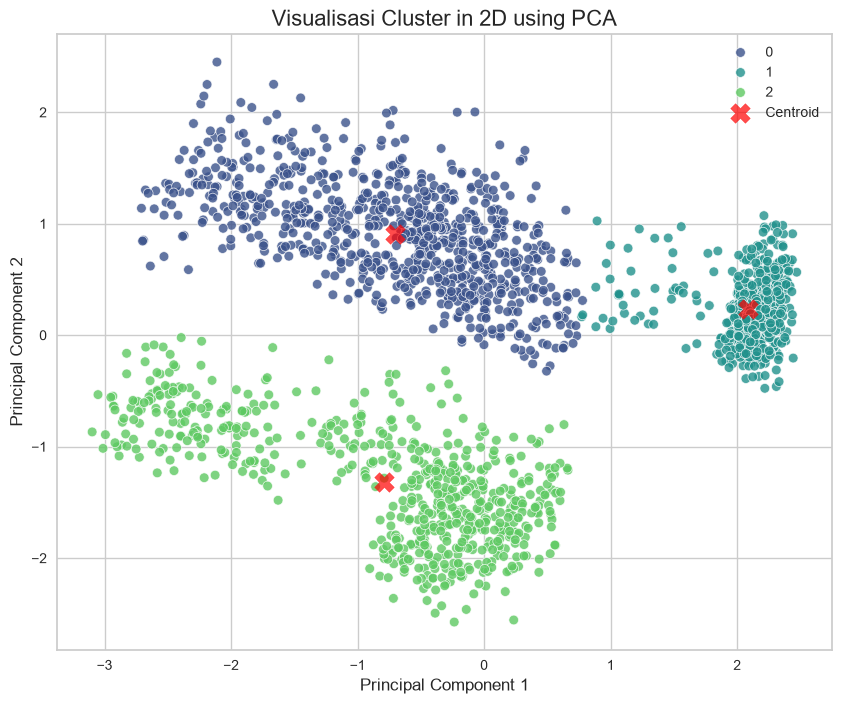

In [24]:
# Instantiate PCA Object for 2 component (n_components=2)
pca = PCA(n_components=2)

# Instantiate PCA Object for 2 component (n_components=2)
df_pca = pca.fit_transform(df)

# Create a new DataFrame named 'df_pca' from the transformation
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Add Cluster column to 'df_pca' using labels from kmeans.labels_ before
df_pca['Cluster'] = model.labels_

# Create a scatterplot using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette=sns.color_palette("viridis", n_colors=3),
    data=df_pca,
    legend="full",
    alpha=0.8
)

# Visualize the Cluster
plt.title('Visualisasi Cluster in 2D using PCA', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()


### Comparison model: K-Means on PCA components
A second K-Means model (also k = 3) is trained on the two PCA components (`PCA1`, `PCA2`) instead of the full feature set, as a comparison to the main model.

In [25]:
# Instantiate PCA Objek using 2 components
pca = PCA(n_components=2)

# Fit the PCA to 'df_used' and fit transform the data
df_pca_array = pca.fit_transform(df_used)

# Create new DataFrane named 'data_final' from the PCA Array
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# instantiate new KMeans Model
kmeans_pca = KMeans(n_clusters=3, random_state=42)

# Fit the new KMeans model (only data_final)
kmeans_pca.fit(data_final)

KMeans(n_clusters=3, random_state=42)

Save the PCA-based model.

In [26]:
# Save PCA Model to .h5 using Joblib
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

## 6. Cluster Interpretation

### Cluster summary (scaled values)
Mean, min, and max of each numeric feature per cluster. Values are still standardized, so 0 means the population average.

In [27]:
# Add new 'Cluster' column from labels (from kmeans.labels_)
df_used['Cluster'] = model.labels_

# Group by 'df_used' by 'Cluster' and count the aggregation for 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Display the summary
display(agg_summary)

Cluster                      0     1     2
TransactionAmount   mean -0.04  0.07 -0.00
                    min  -1.17 -1.18 -1.17
                    max   2.93  2.96  2.89
CustomerAge         mean -0.15 -1.21  1.16
                    min  -1.05 -1.50  0.64
                    max   0.58 -0.94  1.99
TransactionDuration mean  0.00  0.04 -0.04
                    min  -1.55 -1.53 -1.55
                    max   2.56  2.55  2.55
LoginAttempts       mean  0.00  0.00  0.00
                    min   0.00  0.00  0.00
                    max   0.00  0.00  0.00
AccountBalance      mean  0.38 -0.92  0.26
                    min  -1.28 -1.28 -1.27
                    max   2.53  1.18  2.51

**Interpretation (scaled values)**

| Cluster | Mean `CustomerAge` | Mean `AccountBalance` | Mean `TransactionAmount` |
|---|---|---|---|
| 0 | −0.15 | 0.38 | −0.04 |
| 1 | −1.21 | −0.92 | 0.07 |
| 2 | 1.16 | 0.26 | −0.00 |

- **Cluster 0**: age slightly below average, balance above average.
- **Cluster 1**: much younger than average, with the lowest balance of all clusters.
- **Cluster 2**: much older than average, with above-average balance.

`TransactionAmount` and `TransactionDuration` are close to 0 in all clusters, so the clusters are separated mainly by **age and account balance**, not by transaction behavior.

## 7. Export the Data

Rename the cluster label column to `Target` so it can be used as the label for the classification model.

In [28]:
df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Show 5 first rows to verify
df_used.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge,Target
0,-1.111922,1,0,1.426636,0,-0.541568,0.0,0.002918,0,2
1,0.546926,1,0,1.313889,0,0.308502,0.0,2.216531,0,2
2,-0.597984,1,2,-1.448403,3,-0.895763,0.0,-1.018513,1,1
3,-0.331350,1,2,-1.053790,3,-1.334965,0.0,0.887895,1,1
5,-0.754364,1,0,-1.504776,3,0.747704,0.0,-1.105726,1,1


Save the preprocessed (scaled and encoded) dataset with its `Target` label.

In [29]:
# Save the data to csv using .to_csv
df_used.to_csv('data_clustering.csv', index=False)

### Inverse transform to original values
To describe the clusters in real units, the scaling is reversed on a copy of the data (`df_inverse`). First, numeric columns are restored with the fitted `scaler`.

In [30]:
# inverse dataset from normal range for numerical things

df_inverse = df_used.copy()

# use 'scaler' to return 'numerical_cols' as original value.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# show the first 5 rows to verify
df_inverse.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge,Target
0,14.09,1,0,70.0,0,81.0,1.0,5112.21,0,2
1,376.24,1,0,68.0,0,141.0,1.0,13758.91,0,2
2,126.29,1,2,19.0,3,56.0,1.0,1122.35,1,1
3,184.50,1,2,26.0,3,25.0,1.0,8569.06,1,1
5,92.15,1,0,18.0,3,172.0,1.0,781.68,1,1


Next, each categorical column is restored to its original labels with its stored `LabelEncoder`.

In [31]:
for column in categorial_cols:
    # Get the exact encoder for 'column' from 'encoders' directory.
    encoder = encoders[column]

    # use scaler to inverse the column
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# show the first 5 rows to verify
df_inverse.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge,Target
0,14.09,Debit,ATM,70.0,Doctor,81.0,1.0,5112.21,High,2
1,376.24,Debit,ATM,68.0,Doctor,141.0,1.0,13758.91,High,2
2,126.29,Debit,Online,19.0,Student,56.0,1.0,1122.35,Low,1
3,184.50,Debit,Online,26.0,Student,25.0,1.0,8569.06,Low,1
5,92.15,Debit,ATM,18.0,Student,172.0,1.0,781.68,Low,1


### Cluster summary (original values)
Numeric features: mean, min, and max per cluster. Categorical features: the most frequent value (mode) per cluster.

In [32]:
# group by 'df_inverse'by 'Target' and count the aggregation for 'numerical_cols'
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

agg_summary_cat = df_inverse.groupby('Target')[categorial_cols].agg(lambda x: x.mode()[0]).round(2).T

display(agg_summary_num)
display(agg_summary_cat)

Target                           0        1         2
TransactionAmount   mean    247.26   272.68    256.11
                    min       0.32     0.26      1.82
                    max     896.79   903.19    888.57
CustomerAge         mean     41.97    23.19     65.34
                    min      26.00    18.00     56.00
                    max      55.00    28.00     80.00
TransactionDuration mean    119.43   122.17    116.61
                    min      10.00    11.00     10.00
                    max     300.00   299.00    299.00
LoginAttempts       mean      1.00     1.00      1.00
                    min       1.00     1.00      1.00
                    max       1.00     1.00      1.00
AccountBalance      mean   6575.39  1516.39   6131.27
                    min     112.76   102.20    120.89
                    max   14977.99  9716.68  14904.90

Target,0,1,2
TransactionType,Debit,Debit,Debit
Channel,Branch,Branch,ATM
CustomerOccupation,Engineer,Student,Retired
BinnedCustomerAge,Medium,Low,High


**Interpretation (original values)**

1. **Cluster 0: Working-Age Professionals** (797 customers)
   - Mean `CustomerAge`: **42 years** (26–55)
   - Mean `AccountBalance`: **6,575**, the highest of all clusters
   - Mean `TransactionAmount`: 247
   - Occupation: Engineer 51%, Doctor 39%
   - **Analysis:** Established, working-age customers with the largest balances. They transact at a similar level to other clusters, but keep more money in their accounts.

2. **Cluster 1: Young Students** (511 customers)
   - Mean `CustomerAge`: **23 years** (18–28)
   - Mean `AccountBalance`: **1,516**, far lower than the other clusters
   - Mean `TransactionAmount`: 273, slightly the highest
   - Occupation: Student 100%
   - **Analysis:** Students with low balances who still spend at the same level as other groups. Relative to their balance, they spend the most.

3. **Cluster 2: Senior Customers** (637 customers)
   - Mean `CustomerAge`: **65 years** (56–80)
   - Mean `AccountBalance`: **6,131**
   - Mean `TransactionAmount`: 256
   - Occupation: Retired 60%, Doctor 30%
   - **Analysis:** Older customers, mostly retired, with healthy balances.

**Key takeaway:** the segments are mainly **demographic** (life stage and balance). Transaction type, channel, amount, and duration are almost the same across clusters.

### Limitations and future work
- **Outlier removal removed the fraud signal.** After IQR filtering, `LoginAttempts` equals 1 for every row, so all multiple-login transactions (the strongest anomaly signal) were removed. Capping outliers instead of dropping them would keep this information.
- **Label encoding implies an order** for nominal categories such as `CustomerOccupation`. One-hot encoding would avoid this.
- **Moderate separation.** A Silhouette Score of 0.263 means the clusters overlap. They are useful for customer segmentation, but not strong enough on their own for fraud detection.

## 8. Export the Inverse-Transformed Data

Final check of the data in its original units before saving.

In [33]:
df_inverse.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,BinnedCustomerAge,Target
0,14.09,Debit,ATM,70.0,Doctor,81.0,1.0,5112.21,High,2
1,376.24,Debit,ATM,68.0,Doctor,141.0,1.0,13758.91,High,2
2,126.29,Debit,Online,19.0,Student,56.0,1.0,1122.35,Low,1
3,184.50,Debit,Online,26.0,Student,25.0,1.0,8569.06,Low,1
5,92.15,Debit,ATM,18.0,Student,172.0,1.0,781.68,Low,1


Save the inverse-transformed dataset with its `Target` label.

In [34]:
df_inverse.to_csv('data_clustering_inverse.csv', index=False)